In [19]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [20]:
# Load dataset

df = pd.read_csv("healthcare_dataset.csv")

In [21]:
# Display first few rows

df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,31-01-2024,Matthew Smith,Sons and Miller,Blue Cross,18856.28131,328,Urgent,02-02-2024,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,20-08-2019,Samantha Davies,Kim Inc,Medicare,33643.32729,265,Emergency,26-08-2019,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,22-09-2022,Tiffany Mitchell,Cook PLC,Aetna,27955.09608,205,Emergency,07-10-2022,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,18-11-2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78241,450,Elective,18-12-2020,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,19-09-2022,Kathleen Hanna,White-White,Aetna,14238.31781,458,Urgent,09-10-2022,Penicillin,Abnormal


In [22]:
df["Name"] = df["Name"].str.title()

### Data Preprocessing

In [23]:
# Check for missing values
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [24]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                55500 non-null  object        
 1   Age                 55500 non-null  int64         
 2   Gender              55500 non-null  object        
 3   Blood Type          55500 non-null  object        
 4   Medical Condition   55500 non-null  object        
 5   Date of Admission   55500 non-null  datetime64[ns]
 6   Doctor              55500 non-null  object        
 7   Hospital            55500 non-null  object        
 8   Insurance Provider  55500 non-null  object        
 9   Billing Amount      55500 non-null  float64       
 10  Room Number         55500 non-null  int64         
 11  Admission Type      55500 non-null  object        
 12  Discharge Date      55500 non-null  datetime64[ns]
 13  Medication          55500 non-null  object    

In [26]:
# Calculate Length of Stay (LOS)

df['Length of Stay'] = (df["Discharge Date"] - df["Date of Admission"]).dt.days

In [27]:
# Handle incorrect or missing Length of Stay

df.loc[df['Length of Stay'] < 0, 'Length of Stay'] = 0  # Fix negative values
df['Length of Stay'].fillna(df['Length of Stay'].median(), inplace=True)  # Fill missing values with median

### Exploratory Data Analysis (EDA)

In [28]:
# Summary statistics

df.describe()

,Age,Billing Amount,Room Number,Length of Stay
count,55500.000000,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829,49.467550
std,19.602454,14211.454431,115.243069,76.607941
min,13.000000,-2008.492140,101.000000,0.000000
25%,35.000000,13241.224655,202.000000,0.000000
50%,52.000000,25538.069380,302.000000,16.000000
75%,68.000000,37820.508432,401.000000,61.000000
max,89.000000,52764.276740,500.000000,354.000000


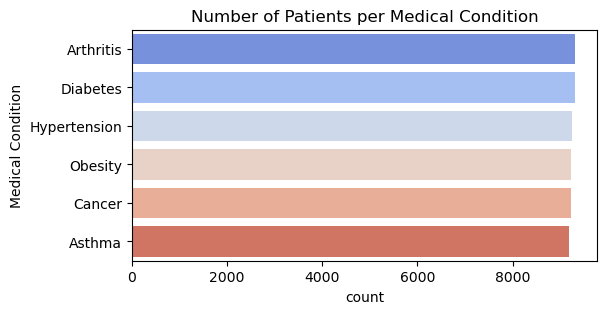

In [29]:
# Count of patients per medical condition

plt.figure(figsize=(6,3))
sns.countplot(data=df, y="Medical Condition", order=df["Medical Condition"].value_counts().index, palette="coolwarm")
plt.title("Number of Patients per Medical Condition")
plt.show()

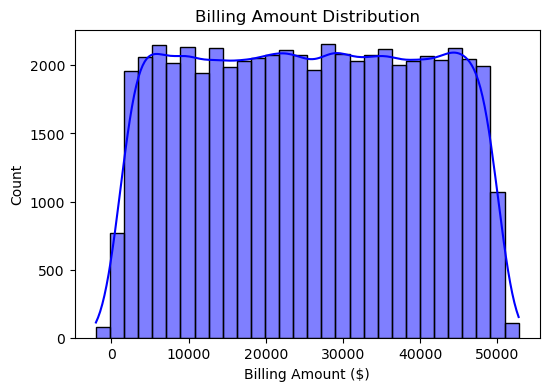

In [30]:
# Distribution of Billing Amount

plt.figure(figsize=(6,4))
sns.histplot(df['Billing Amount'], bins=30, kde=True, color="blue")
plt.title("Billing Amount Distribution")
plt.xlabel("Billing Amount ($)")
plt.show()

### Key Metrics Analysis

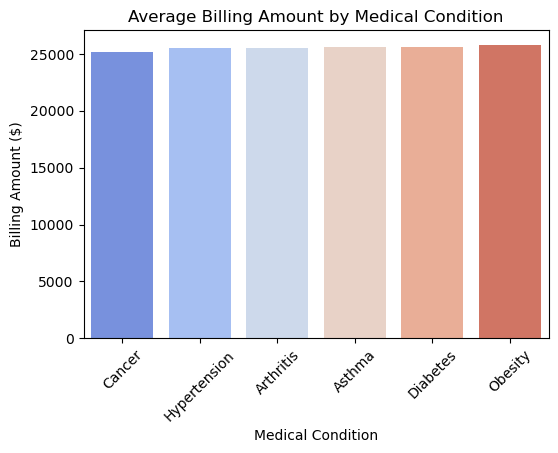

In [31]:
# Average billing amount per medical condition

billing_by_condition = df.groupby("Medical Condition")["Billing Amount"].mean().sort_values()
plt.figure(figsize=(6,4))
sns.barplot(x=billing_by_condition.index, y=billing_by_condition.values, palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Average Billing Amount by Medical Condition")
plt.ylabel("Billing Amount ($)")
plt.show()

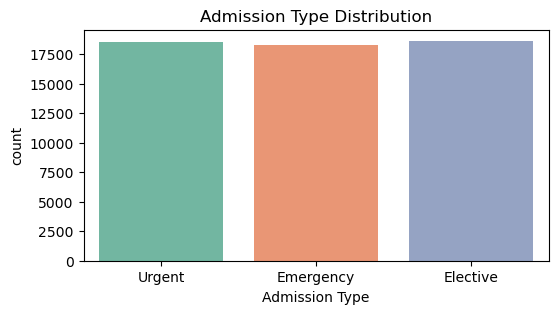

In [32]:
# Admission Type Distribution

plt.figure(figsize=(6,3))
sns.countplot(data=df, x="Admission Type", palette="Set2")
plt.title("Admission Type Distribution")
plt.show()

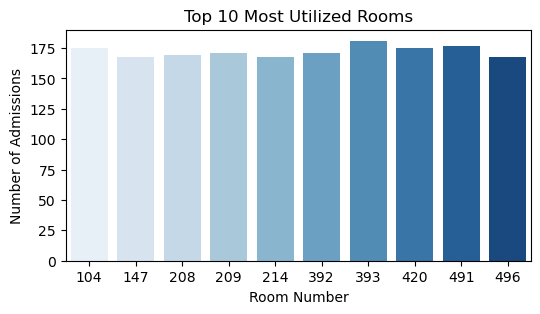

In [33]:
# Room Utilization - Patients per Room

room_utilization = df["Room Number"].value_counts().head(10)  # Top 10 most occupied rooms
plt.figure(figsize=(6,3))
sns.barplot(x=room_utilization.index, y=room_utilization.values, palette="Blues")
plt.title("Top 10 Most Utilized Rooms")
plt.xlabel("Room Number")
plt.ylabel("Number of Admissions")
plt.show()

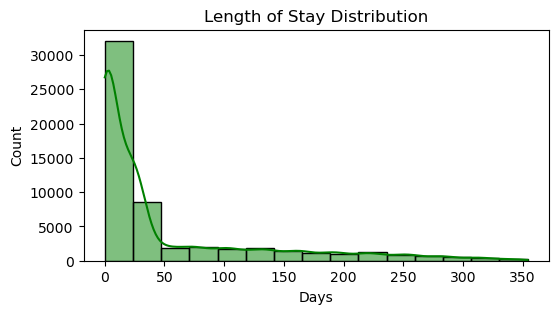

In [34]:
# Length of Stay Analysis

plt.figure(figsize=(6,3))
sns.histplot(df['Length of Stay'], bins=15, kde=True, color="green")
plt.title("Length of Stay Distribution")
plt.xlabel("Days")
plt.show()

### Recommendations

In [35]:
# Identify High Cost Patients (Top 5%)

high_cost_threshold = df["Billing Amount"].quantile(0.95)
high_cost_patients = df[df["Billing Amount"] > high_cost_threshold]

high_cost_patients[['Name', 'Medical Condition', 'Billing Amount']].head()

,Name,Medical Condition,Billing Amount
5,Emily Johnson,Asthma,48145.11095
8,Jasmine Aguilar,Asthma,50119.22279
30,Thomas Martinez,Asthma,47909.12881
38,Nicole Lucero,Diabetes,48290.69341
40,Christopher Lee,Hypertension,49943.27850


In [36]:
# Identify Long Stay Patients (Top 5%)

long_stay_threshold = df["Length of Stay"].quantile(0.95)
long_stay_patients = df[df["Length of Stay"] > long_stay_threshold]

long_stay_patients[['Name', 'Medical Condition', 'Length of Stay']].head()

,Name,Medical Condition,Length of Stay
6,Edward Edwards,Diabetes,249
15,Ms. Natalie Gamble,Obesity,304
23,Dr. Eileen Thompson,Asthma,303
29,Joshua Oliver,Hypertension,275
31,James Patterson,Arthritis,263
